# Airbnb Occupancy Analysis with PySpark

This notebook builds a binary classifier to predict whether an Airbnb listing will have high occupancy. It handles data loading, cleaning, feature engineering, and trains both a Logistic Regression and a Random Forest model using PySpark MLlib.

In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pathlib import Path

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42


/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
spark = SparkSession.builder.appName("airbnb-analysis-pyspark").getOrCreate()
print("Spark session started")


Spark session started


26/05/02 01:16:22 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## Input Path

We try several candidate file paths to locate the cleaned dataset produced by the earlier cleaning pipeline. Spark writes CSV output as a folder of `part-*.csv` files rather than a single file, so both folder and file paths are checked.

In [3]:
DATA_PATH_CANDIDATES = [
    "airbnb_cleaned",
    "airbnb_cleaned_single",
    "listings_cleaned_pyspark.csv",
    "airbnb_cleaned.csv",
    "listings_cleaned.csv",
    "listings.csv",
]

def pick_existing_path(paths):
    for p in paths:
        if Path(p).exists():
            return p
    raise FileNotFoundError(f"No input dataset found. Checked: {paths}")

DATA_PATH = pick_existing_path(DATA_PATH_CANDIDATES)
print("Using dataset:", DATA_PATH)


Using dataset: airbnb_cleaned


In [4]:
df_raw = spark.read.csv(DATA_PATH, header=True, inferSchema=False)

print(f"Raw shape: ({df_raw.count()}, {len(df_raw.columns)})")
df_raw.show(3, truncate=False)
df_raw.printSchema()


Raw shape: (101661, 28)


26/05/02 01:16:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------------+---------------------------+---------------------------------------------------------------------------------------------------+----------------------+---------+-------------------+-------------+----------+--------+---------+-------------+----------------+-------------------+---------+-----------------+------+-----------+--------------+-----------------+-----------+-----------------+------------------+------------------------------+----------------+-----------+------------+------------+--------------+
|id                |name                       |host_id                                                                                            |host_identity_verified|host_name|neighbourhood_group|neighbourhood|lat       |long    |country  |country_code |instant_bookable|cancellation_policy|room_type|construction_year|price |service_fee|minimum_nights|number_of_reviews|last_review|reviews_per_month|review_rate_number|calculated_host_listings_count|availability_365|

## Helper Functions

`safe_double_expr` strips non-numeric characters from a string column and safely casts it to a double, returning null for anything that cannot be parsed. `cap_outliers` clips extreme values at a specified lower and upper percentile. `print_classification_metrics` computes accuracy, F1, and ROC-AUC for a set of predictions and prints a breakdown by class. `require_columns` validates that all required columns are present before a step runs.

In [5]:
def safe_double_expr(col_name):
    cleaned = F.regexp_replace(
        F.trim(F.col(col_name).cast("string")),
        r"[^0-9.-]",
        ""
    )

    return (
        F.when(
            (cleaned == "") |
            (cleaned == ".") |
            (cleaned == "-") |
            (cleaned == "-.") |
            (cleaned == ".-"),
            None
        )
        .when(cleaned.rlike(r"^-?\d+(\.\d+)?$"), cleaned.cast("double"))
        .otherwise(None)
    )


def safe_to_double(df, col_name):
    if col_name not in df.columns:
        return df
    return df.withColumn(col_name, safe_double_expr(col_name))


def cap_outliers(df, col_name, lower=0.01, upper=0.99):
    if col_name not in df.columns:
        return df

    quantiles = df.where(F.col(col_name).isNotNull()).approxQuantile(col_name, [lower, upper], 0.001)
    if len(quantiles) != 2:
        return df

    lo, hi = quantiles
    return df.withColumn(
        col_name,
        F.when(F.col(col_name) < lo, lo)
         .when(F.col(col_name) > hi, hi)
         .otherwise(F.col(col_name))
    )


def print_classification_metrics(preds, title):
    acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    ).evaluate(preds)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1"
    ).evaluate(preds)

    auc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    ).evaluate(preds)

    print(f"\n=== {title} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1:       {f1:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    print("Prediction breakdown:")
    preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

    return {"Accuracy": acc, "F1": f1, "ROC-AUC": auc}


def require_columns(df, cols, context):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for {context}: {missing}")


## Missing Data Overview

We compute the fraction of null values per column and visualize the top 30 columns with the most missing data as a horizontal bar chart. This gives a quick picture of which columns might need imputation or dropping.

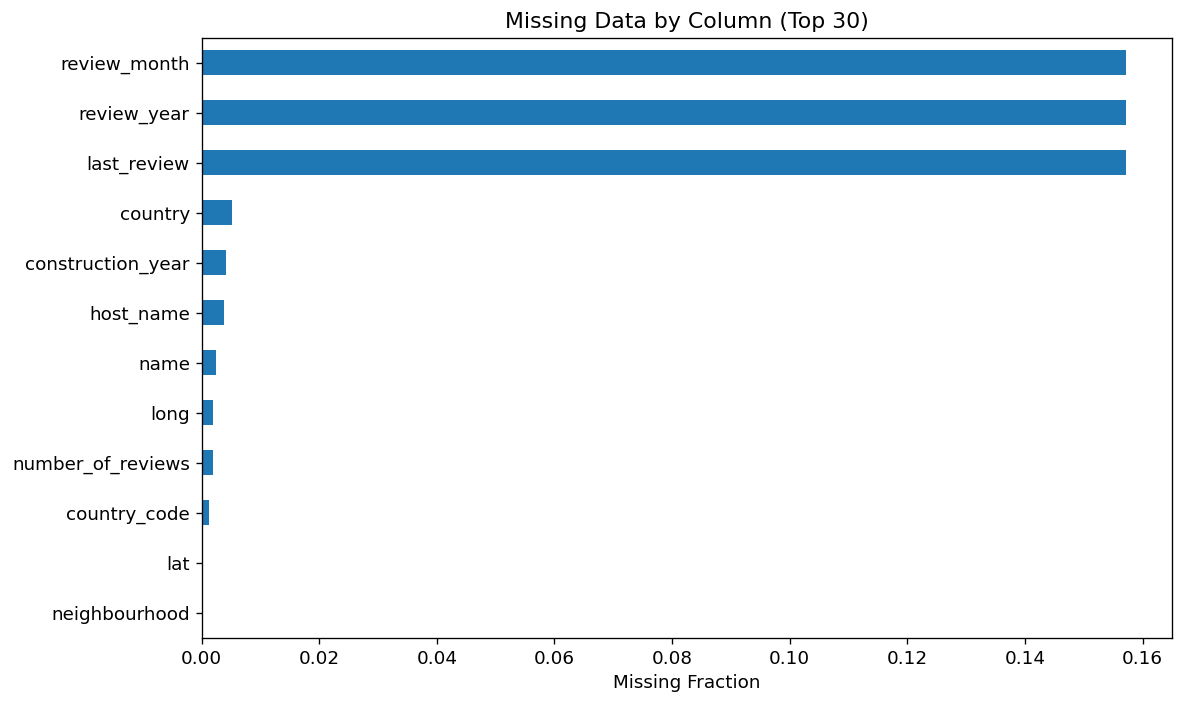

Columns with >50% missing among top 30: 0


,missing_fraction
last_review,0.157209
review_year,0.157209
review_month,0.157209
country,0.005164
construction_year,0.004122
host_name,0.003895
name,0.002420
long,0.002017
number_of_reviews,0.001977
country_code,0.001239


In [6]:
missing = (
    df_raw.select(
        *[F.avg(F.col(c).isNull().cast("double")).alias(c) for c in df_raw.columns]
    )
    .toPandas()
    .T
)
missing.columns = ["missing_fraction"]
missing = missing.sort_values("missing_fraction", ascending=False).head(30)

missing_nonzero = missing[missing["missing_fraction"] > 0]

if not missing_nonzero.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_nonzero.sort_values("missing_fraction").plot(kind="barh", ax=ax, legend=False)
    ax.set_xlabel("Missing Fraction")
    ax.set_title("Missing Data by Column (Top 30)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in top 30 columns.")

print(f"Columns with >50% missing among top 30: {(missing['missing_fraction'] > 0.5).sum()}")
missing.head(10)


## Drop High-Cardinality Metadata Columns

Columns like URLs, free-text descriptions, and scraped timestamps add no predictive signal and would inflate the dataset unnecessarily. We drop them before any modeling work begins.

In [7]:
df = df_raw

drop_cols = [
    "listing_url", "scrape_id", "last_scraped", "source", "name",
    "description", "neighborhood_overview", "picture_url", "host_url",
    "host_profile_url", "host_thumbnail_url", "host_picture_url",
    "host_about", "host_verifications", "calendar_updated",
    "calendar_last_scraped", "first_review", "last_review", "license",
    "amenities", "bathrooms_text", "neighbourhood", "host_neighbourhood",
    "neighbourhood_group_cleansed", "price", "estimated_revenue_l365d",
    "host_since", "host_response_rate", "host_acceptance_rate",
    "host_response_time", "host_total_listings_count", "instant_bookable",
    "host_is_superhost", "host_has_profile_pic", "host_identity_verified",
    "has_availability",
]

drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(*drop_cols)

print(f"After dropping metadata/null cols: ({df.count()}, {len(df.columns)})")
print("Dropped columns:", drop_cols)


After dropping metadata/null cols: (101661, 22)
Dropped columns: ['name', 'last_review', 'neighbourhood', 'price', 'instant_bookable', 'host_identity_verified']


## Numeric Cleaning and Median Imputation

We cast all numeric columns to doubles using `safe_to_double`, which handles formatting characters that may remain in the data. Missing values are then filled with each column's median, computed efficiently via approximate quantiles.

In [8]:
num_cols = [
    "accommodates", "bathrooms", "bedrooms", "beds", "minimum_nights",
    "maximum_nights", "reviews_per_month", "review_scores_rating",
    "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
    "review_scores_location", "review_scores_value", "number_of_reviews",
    "number_of_reviews_ltm", "number_of_reviews_l30d", "availability_30",
    "availability_60", "availability_90", "availability_365", "availability_eoy",
    "calculated_host_listings_count", "host_listings_count", "estimated_occupancy_l365d",
    "hosts_time_as_user_years", "hosts_time_as_host_years", "latitude", "longitude",
]

num_cols = [c for c in num_cols if c in df.columns]

for col_name in num_cols:
    df = safe_to_double(df, col_name)
    med = df.where(F.col(col_name).isNotNull()).approxQuantile(col_name, [0.5], 0.001)
    if med:
        df = df.fillna({col_name: float(med[0])})

print("Numeric columns cleaned and imputed with median.")
print("Numeric columns used:", num_cols)


Numeric columns cleaned and imputed with median.
Numeric columns used: ['minimum_nights', 'reviews_per_month', 'number_of_reviews', 'availability_365', 'calculated_host_listings_count']


## Categorical Cleaning

String columns are trimmed and null values are replaced with the placeholder `Unknown`. Room type and property type are collapsed so that rare or unrecognized values are grouped into an `Other` category, which helps keep the label space manageable. Neighbourhood values outside the top 20 are similarly grouped.

In [9]:
cat_cols = [c for c in ["room_type", "property_type", "neighbourhood_cleansed"] if c in df.columns]

for col_name in cat_cols:
    df = df.withColumn(col_name, F.trim(F.coalesce(F.col(col_name).cast("string"), F.lit("Unknown"))))

if "room_type" in df.columns:
    valid_room_types = ["Entire home/apt", "Private room", "Shared room", "Hotel room"]
    df = df.withColumn(
        "room_type",
        F.when(F.col("room_type").isin(valid_room_types), F.col("room_type")).otherwise(F.lit("Other"))
    )

if "property_type" in df.columns:
    top_props = [
        r["property_type"]
        for r in df.groupBy("property_type").count().orderBy(F.desc("count")).limit(10).collect()
    ]
    df = df.withColumn(
        "property_type",
        F.when(F.col("property_type").isin(top_props), F.col("property_type")).otherwise(F.lit("Other"))
    )

if "neighbourhood_cleansed" in df.columns:
    top_hoods = [
        r["neighbourhood_cleansed"]
        for r in df.groupBy("neighbourhood_cleansed").count().orderBy(F.desc("count")).limit(20).collect()
    ]
    df = df.withColumn(
        "neighbourhood_cleansed",
        F.when(F.col("neighbourhood_cleansed").isin(top_hoods), F.col("neighbourhood_cleansed")).otherwise(F.lit("Other"))
    )

print("Categorical columns cleaned.")
print("Categorical columns used:", cat_cols)


Categorical columns cleaned.
Categorical columns used: ['room_type']


## Outlier Capping

For columns like `minimum_nights`, `accommodates`, and `beds`, we cap values at the 1st and 99th percentiles. This prevents extreme outliers from distorting the feature space without removing rows.

In [10]:
for c in ["minimum_nights", "maximum_nights", "accommodates", "beds", "bedrooms"]:
    if c in df.columns:
        df = cap_outliers(df, c)

print(f"Final cleaned shape: ({df.count()}, {len(df.columns)})")


Final cleaned shape: (101661, 22)


## Save Cleaned Analysis Dataset

The cleaned DataFrame is written to a single CSV folder. This file can also be used as input for the classification and pricing notebooks.

In [11]:
OUTPUT_CLEANED_PATH = "listings_cleaned_pyspark"

df.coalesce(1).write.mode("overwrite").option("header", True).csv(OUTPUT_CLEANED_PATH)
print(f"Saved cleaned data to folder: {OUTPUT_CLEANED_PATH}/")


[Stage 20:>                                                         (0 + 1) / 1]

Saved cleaned data to folder: listings_cleaned_pyspark/


## Descriptive Statistics

We pull up to 100,000 rows into a pandas DataFrame and print summary statistics for all columns. This gives a quick sanity check on value ranges, means, and counts after cleaning.

In [12]:
df_pd = df.limit(100000).toPandas()
print(df_pd.describe(include="all").T)


                                   count  unique                 top   freq  \
id                                100000  100000  A FAMILY OF TWO"""      1   
host_id                           100000   99849            verified     84   
host_name                          99607   13038             Michael    852   
neighbourhood_group               100000      84           Manhattan  42527   
lat                                99980   22011            40.76411     36   
long                               99841   17681           -73.99371     44   
country                            99475      13       United States  99312   
country_code                       99874       4                  US  99711   
cancellation_policy               100000       8            moderate  33483   
room_type                         100000       5     Entire home/apt  52277   
construction_year                  99627      20              2014.0   5097   
service_fee                       100000     246    

## Room Type and Property Type Distributions

A pie chart shows the share of listings by room type, and a horizontal bar chart shows the top 10 property types by count. These distributions contextualize the dataset before modeling.

In [13]:
if "room_type" in df_pd.columns and "property_type" in df_pd.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    rt_counts = df_pd["room_type"].value_counts()
    axes[0].pie(rt_counts, labels=rt_counts.index, autopct="%1.1f%%")
    axes[0].set_title("Room Type Distribution")

    df_pd["property_type"].value_counts().nlargest(10).sort_values().plot(kind="barh", ax=axes[1])
    axes[1].set_title("Top 10 Property Types")
    axes[1].set_xlabel("Listings")

    plt.tight_layout()
    plt.show()
else:
    print("Skipping distribution plots: room_type or property_type column is missing.")


Skipping distribution plots: room_type or property_type column is missing.


## Create High-Occupancy Target

We define a binary target called `high_occupancy`. A listing is labeled 1 if its estimated occupancy over the last 365 days is 60 days or more, and 0 otherwise. If the occupancy column is absent, we derive it as `365 - availability_365` as a proxy. The positive class rate is printed to check for class imbalance.

In [14]:
from pyspark.sql import functions as F

if "estimated_occupancy_l365d" in df.columns:
    df = df.withColumn(
        "estimated_occupancy_l365d",
        F.col("estimated_occupancy_l365d").cast("double")
    )

    df_ml = df.withColumn(
        "high_occupancy",
        (F.col("estimated_occupancy_l365d") >= 60).cast("int")
    )

    print("Using estimated_occupancy_l365d to create target.")

elif "availability_365" in df.columns:
    df = df.withColumn(
        "availability_365",
        F.col("availability_365").cast("double")
    )

    df_ml = df.withColumn(
        "estimated_occupancy_l365d",
        365 - F.col("availability_365")
    )

    df_ml = df_ml.withColumn(
        "high_occupancy",
        (F.col("estimated_occupancy_l365d") >= 60).cast("int")
    )

    print("estimated_occupancy_l365d not found.")
    print("Created estimated_occupancy_l365d as 365 - availability_365.")

else:
    raise ValueError(
        "Cannot create high_occupancy target. Need either estimated_occupancy_l365d or availability_365."
    )

print("Target distribution:")
df_ml.groupBy("high_occupancy").count().orderBy("high_occupancy").show()

pos_rate = df_ml.agg(F.avg("high_occupancy").alias("pos")).first()["pos"]
print(f"Positive class rate: {pos_rate:.2%}")

estimated_occupancy_l365d not found.
Created estimated_occupancy_l365d as 365 - availability_365.
Target distribution:
+--------------+-----+
|high_occupancy|count|
+--------------+-----+
|             0|16936|
|             1|84725|
+--------------+-----+

Positive class rate: 83.34%


## Feature Engineering

Two new features are derived: `beds_per_person` captures how generously a listing is equipped relative to its capacity, and `review_engagement` combines review frequency with total review count as a proxy for popularity. Categorical columns are label-encoded using `StringIndexer` so they can be consumed by the ML models.

In [15]:
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

if "beds" in df_ml.columns and "accommodates" in df_ml.columns:
    df_ml = df_ml.withColumn(
        "beds_per_person",
        F.col("beds") / (F.col("accommodates") + F.lit(1e-5))
    )

if "reviews_per_month" in df_ml.columns and "number_of_reviews" in df_ml.columns:
    df_ml = df_ml.withColumn(
        "review_engagement",
        F.coalesce(F.col("reviews_per_month"), F.lit(0.0)) * F.col("number_of_reviews")
    )

cat_cols = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "neighbourhood_group",
    "neighbourhood",
    "cancellation_policy",
    "host_identity_verified",
    "instant_bookable"
]

existing_encoded_cols = [
    f"{cat}_enc"
    for cat in cat_cols
    if f"{cat}_enc" in df_ml.columns
]

if existing_encoded_cols:
    df_ml = df_ml.drop(*existing_encoded_cols)

indexer_stages = []

for cat in cat_cols:
    if cat in df_ml.columns:
        df_ml = df_ml.withColumn(cat, F.coalesce(F.col(cat).cast("string"), F.lit("Unknown")))

        indexer_stages.append(
            StringIndexer(
                inputCol=cat,
                outputCol=f"{cat}_enc",
                handleInvalid="keep"
            )
        )

if indexer_stages:
    indexer_pipeline = Pipeline(stages=indexer_stages)
    indexer_model = indexer_pipeline.fit(df_ml)
    df_ml = indexer_model.transform(df_ml)

print("Feature engineering completed.")
print("Columns now available:")
print(df_ml.columns)

Feature engineering completed.
Columns now available:
['id', 'host_id', 'host_name', 'neighbourhood_group', 'lat', 'long', 'country', 'country_code', 'cancellation_policy', 'room_type', 'construction_year', 'service_fee', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'review_year', 'review_month', 'host_type', 'price_category', 'estimated_occupancy_l365d', 'high_occupancy', 'review_engagement', 'room_type_enc', 'neighbourhood_group_enc', 'cancellation_policy_enc']


## Build Model Dataset

We select the final set of features, excluding any columns that would constitute data leakage (such as availability or price). The DataFrame is split 80/20 into training and test sets.

In [16]:
candidate_features = [
    "lat",
    "long",
    "construction_year",
    "service_fee",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "calculated_host_listings_count",
    "review_engagement",
    "room_type_enc",
    "neighbourhood_group_enc",
    "cancellation_policy_enc"
]

leakage_cols = [
    "price",
    "price_category",
    "price_num",
    "price_clean",
    "estimated_occupancy_l365d",
    "high_occupancy",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_ratio",
    "availability_eoy"
]

features = [
    f for f in candidate_features
    if f in df_ml.columns and f not in leakage_cols
]

print("Final features:")
print(features)
print("Number of features:", len(features))

if not features:
    raise ValueError("No usable features were found for modeling.")

df_model = (
    df_ml
    .select(*(features + ["high_occupancy"]))
    .fillna(0.0)
    .withColumnRenamed("high_occupancy", "label")
)

train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=SEED)

print("Train:", (train_df.count(), len(train_df.columns)))
print("Test:", (test_df.count(), len(test_df.columns)))

Final features:
['lat', 'long', 'construction_year', 'service_fee', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'review_engagement', 'room_type_enc', 'neighbourhood_group_enc', 'cancellation_policy_enc']
Number of features: 13


Train: (81431, 14)


[Stage 50:>                                                         (0 + 3) / 3]

Test: (20230, 14)


## Assemble and Scale Features

`VectorAssembler` combines all individual feature columns into a single feature vector. `StandardScaler` then standardizes each feature to unit variance. Scaling is fit on the training set only and applied to both train and test to prevent information leakage.

In [17]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql import functions as F

for f in features:
    train_df = train_df.withColumn(f, F.col(f).cast("double"))
    test_df = test_df.withColumn(f, F.col(f).cast("double"))

train_df = train_df.fillna(0.0, subset=features)
test_df = test_df.fillna(0.0, subset=features)

print("Feature column types:")
train_df.select(features).printSchema()

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

train_vec = assembler.transform(train_df)
test_vec = assembler.transform(test_df)

scaler_model = scaler.fit(train_vec)

train_scaled = scaler_model.transform(train_vec)
test_scaled = scaler_model.transform(test_vec)

print("Feature vectors assembled and scaled.")

Feature column types:
root
 |-- lat: double (nullable = false)
 |-- long: double (nullable = false)
 |-- construction_year: double (nullable = false)
 |-- service_fee: double (nullable = false)
 |-- minimum_nights: double (nullable = false)
 |-- number_of_reviews: double (nullable = false)
 |-- reviews_per_month: double (nullable = false)
 |-- review_rate_number: double (nullable = false)
 |-- calculated_host_listings_count: double (nullable = false)
 |-- review_engagement: double (nullable = false)
 |-- room_type_enc: double (nullable = false)
 |-- neighbourhood_group_enc: double (nullable = false)
 |-- cancellation_policy_enc: double (nullable = false)



[Stage 53:>                                                         (0 + 3) / 3]

Feature vectors assembled and scaled.


## Logistic Regression

We train a Logistic Regression model on the scaled feature vectors. It serves as a linear baseline and is generally faster to train than tree-based models.

In [18]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=1000,
    regParam=0.0,
    elasticNetParam=0.0,
)

lr_model = lr.fit(train_scaled)
lr_preds = lr_model.transform(test_scaled)
lr_metrics = print_classification_metrics(lr_preds, "Logistic Regression")



=== Logistic Regression ===
Accuracy: 0.8322
F1:       0.7663
ROC-AUC:  0.6440
Prediction breakdown:


[Stage 146:>                                                        (0 + 3) / 3]

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|  102|
|    0|       1.0| 3263|
|    1|       0.0|  132|
|    1|       1.0|16733|
+-----+----------+-----+



## Random Forest

We train a Random Forest with 30 trees. Unlike Logistic Regression, it can capture non-linear relationships between features and the target. It also operates on unscaled features, so it uses the raw assembled vectors.

In [19]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features_raw",
    labelCol="label",
    numTrees=30,
    maxDepth=6,
    minInstancesPerNode=20,
    maxBins=32,
    subsamplingRate=0.7,
    featureSubsetStrategy="sqrt",
    seed=SEED
)

rf_model = rf.fit(train_vec)
rf_preds = rf_model.transform(test_vec)
rf_metrics = print_classification_metrics(rf_preds, "Random Forest")


=== Random Forest ===
Accuracy: 0.8391
F1:       0.7787
ROC-AUC:  0.7186
Prediction breakdown:


[Stage 183:======================================>                  (2 + 1) / 3]

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|  208|
|    0|       1.0| 3157|
|    1|       0.0|   99|
|    1|       1.0|16766|
+-----+----------+-----+



## Model Comparison

Accuracy, F1, and ROC-AUC scores for both models are displayed side by side in a grouped bar chart, making it easy to see which model performs better across the three metrics.

                     Accuracy        F1   ROC-AUC
Model                                            
Logistic Regression  0.832180  0.766309  0.644046
Random Forest        0.839051  0.778722  0.718581


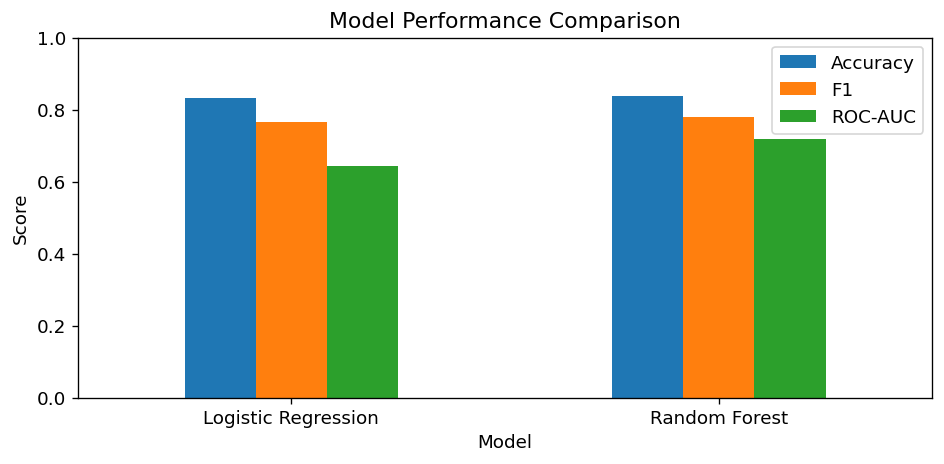

In [20]:
metrics_df = pd.DataFrame(
    [
        {"Model": "Logistic Regression", **lr_metrics},
        {"Model": "Random Forest", **rf_metrics},
    ]
).set_index("Model")

print(metrics_df)

fig, ax = plt.subplots(figsize=(8, 4))
metrics_df[["Accuracy", "F1", "ROC-AUC"]].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Random Forest Feature Importances

The feature importances from the Random Forest model are extracted and plotted. Higher importance means the feature contributed more to the splits across all trees. This helps identify which signals most strongly predict high occupancy.

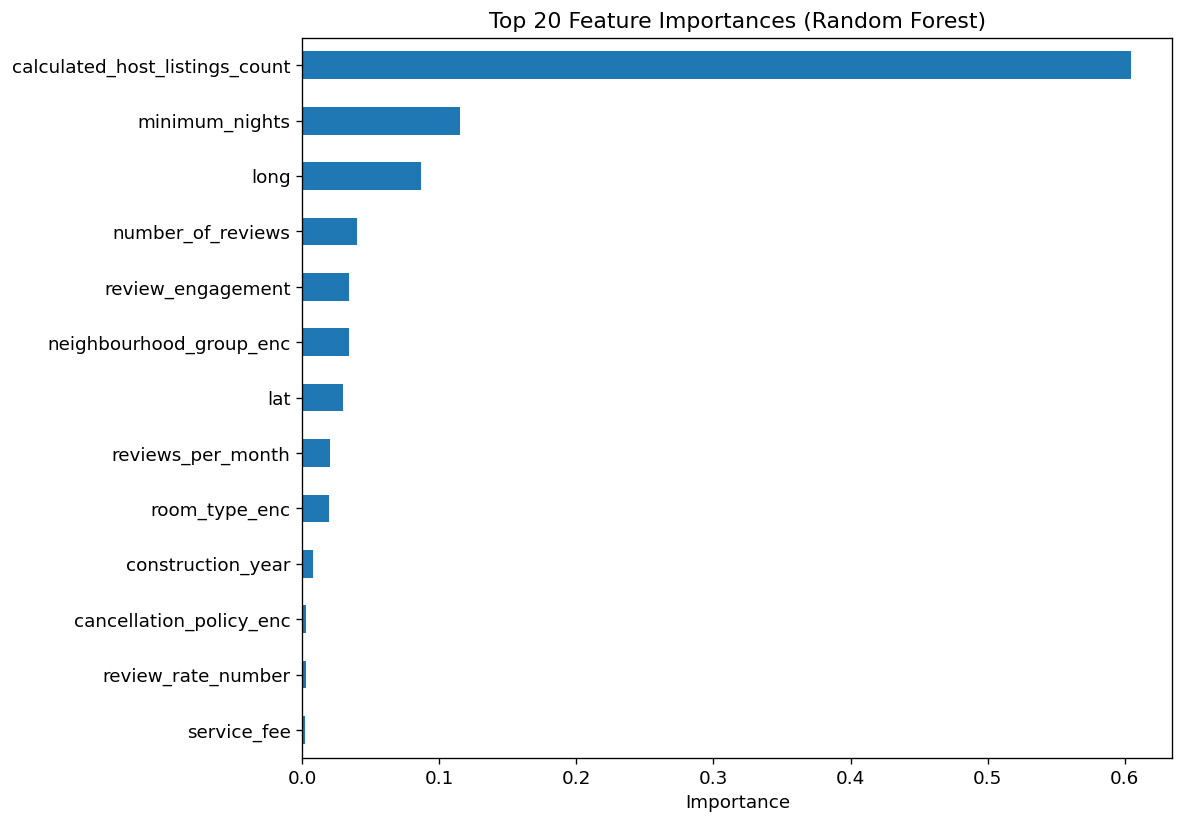

Top 10 features:
calculated_host_listings_count    0.604640
minimum_nights                    0.114844
long                              0.086761
number_of_reviews                 0.040172
review_engagement                 0.034361
neighbourhood_group_enc           0.034258
lat                               0.029432
reviews_per_month                 0.019876
room_type_enc                     0.019386
construction_year                 0.007969


In [21]:
importances = (
    pd.Series(rf_model.featureImportances.toArray(), index=features)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).to_string())


## High-Occupancy Rate by Room Type

We compute the proportion of high-occupancy listings within each room type and plot the results as a bar chart. This reveals whether certain listing types are systematically more likely to be occupied.

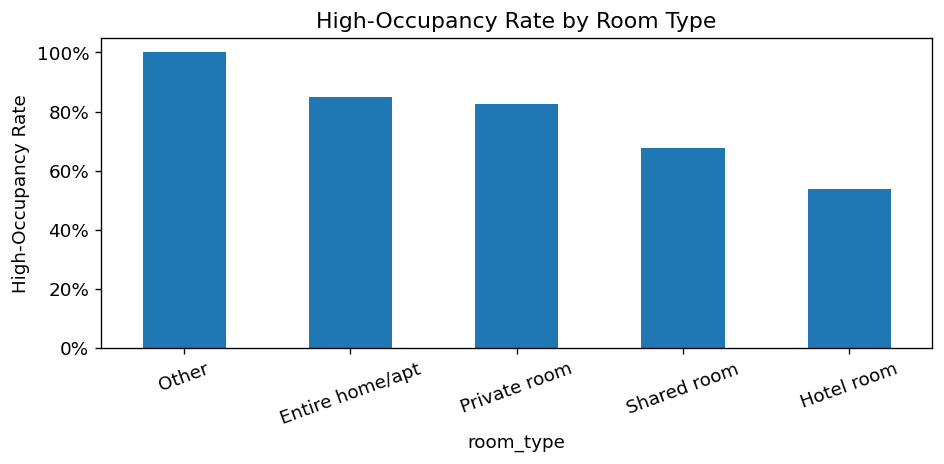

In [22]:
df_ml_pd = df_ml.limit(100000).toPandas()

if "room_type" in df_ml_pd.columns:
    rt_occ = df_ml_pd.groupby("room_type")["high_occupancy"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    rt_occ.plot(kind="bar", ax=ax)
    ax.set_title("High-Occupancy Rate by Room Type")
    ax.set_ylabel("High-Occupancy Rate")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping room type occupancy plot: room_type column is missing.")


## High-Occupancy Rate by Rating Bucket

Review scores are grouped into five buckets and we compare the high-occupancy rate across them. This shows whether higher-rated listings tend to attract more bookings.

In [23]:
if "review_scores_rating" in df_ml_pd.columns:
    df_ml_pd["rating_bucket"] = pd.cut(
        df_ml_pd["review_scores_rating"],
        bins=[0, 3.5, 4.0, 4.5, 4.7, 5.0],
        labels=["< 3.5", "3.5-4.0", "4.0-4.5", "4.5-4.7", "4.7-5.0"],
    )

    rating_occ = df_ml_pd.groupby("rating_bucket", observed=False)["high_occupancy"].mean()

    fig, ax = plt.subplots(figsize=(8, 4))
    rating_occ.plot(kind="bar", ax=ax)
    ax.set_title("High-Occupancy Rate by Rating Bucket")
    ax.set_ylabel("High-Occupancy Rate")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping rating bucket plot: review_scores_rating column is missing.")


Skipping rating bucket plot: review_scores_rating column is missing.


## Neighbourhood Performance

For each neighbourhood, we compute the total number of listings, the high-occupancy rate, and the median estimated occupancy. The top 15 neighbourhoods by high-occupancy rate are displayed.

In [24]:
if "neighbourhood_cleansed" in df_ml.columns:
    hood_stats = (
        df_ml.groupBy("neighbourhood_cleansed")
        .agg(
            F.count("high_occupancy").alias("listings"),
            F.avg("high_occupancy").alias("high_occ_rate"),
            F.expr("percentile_approx(estimated_occupancy_l365d, 0.5)").alias("median_occupancy"),
        )
        .orderBy(F.desc("high_occ_rate"))
    )

    print("Neighbourhood Performance (Top 15 by High Occupancy Rate):")
    hood_stats.show(15, truncate=False)
else:
    print("Skipping neighbourhood performance: neighbourhood_cleansed column is missing.")


Skipping neighbourhood performance: neighbourhood_cleansed column is missing.


## Stop Spark

Uncomment and run this cell when you are done with the notebook to release the Spark session and free resources.

In [25]:
# spark.stop()
